# AI Intern Support Chatbot — NLP FAQ + Historical Tickets


## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")


Libraries imported successfully!


##  Load the FAQ and Support Ticket Data

In [2]:
faq = pd.read_csv("intern_faq_dataset.csv")
tickets = pd.read_csv("historical_support_tickets.csv")

print("FAQ records:", faq.shape)
print("Historical tickets:", tickets.shape)

display(faq.head())
display(tickets.head())


FAQ records: (20, 5)
Historical tickets: (500, 7)


,faq_id,category,question,answer,keywords
0,FAQ001,General,How do I access my internship portal?,Use the internship portal link provided by HR....,"portal, login, access"
1,FAQ002,Attendance,How do I mark my daily attendance?,Open the attendance section of the internship ...,"attendance, check in, daily attendance"
2,FAQ003,Attendance,What should I do if I forget to mark attendance?,Inform your supervisor or HR as soon as possib...,"attendance, forgot, correction"
3,FAQ004,Tasks,Where can I see my assigned tasks?,Assigned tasks are normally available in the p...,"tasks, assignments, dashboard"
4,FAQ005,Tasks,What should I do if I do not understand a task?,"Read the task description first, then ask your...","task, clarification, mentor, supervisor"


,ticket_id,intern_id,query,category,subject,resolution,status
0,TKT0001,INT029,I want feedback about my recent work,Feedback,Performance feedback,Ask your mentor or supervisor for feedback dur...,Resolved
1,TKT0002,INT190,I cannot log into the internship portal,General,Portal login issue,Use the internship portal link provided by HR....,Resolved
2,TKT0003,INT063,I do not understand what my assigned task requ...,Tasks,Task clarification,Assigned tasks are normally available in the p...,Resolved
3,TKT0004,INT036,I need more time to finish my assignment,Deadline,Deadline extension request,"Tell your supervisor before the deadline, expl...",Resolved
4,TKT0005,INT027,What are the internship working hours?,Working Hours,Schedule question,Follow the working hours communicated by your ...,Resolved


## Understand the Data


In [3]:
print("FAQ missing values:")
print(faq.isnull().sum())

print("\nTicket missing values:")
print(tickets.isnull().sum())


FAQ missing values:
faq_id      0
category    0
question    0
answer      0
keywords    0
dtype: int64

Ticket missing values:
ticket_id     0
intern_id     0
query         0
category      0
subject       0
resolution    0
status        0
dtype: int64


## Explore Support Categories

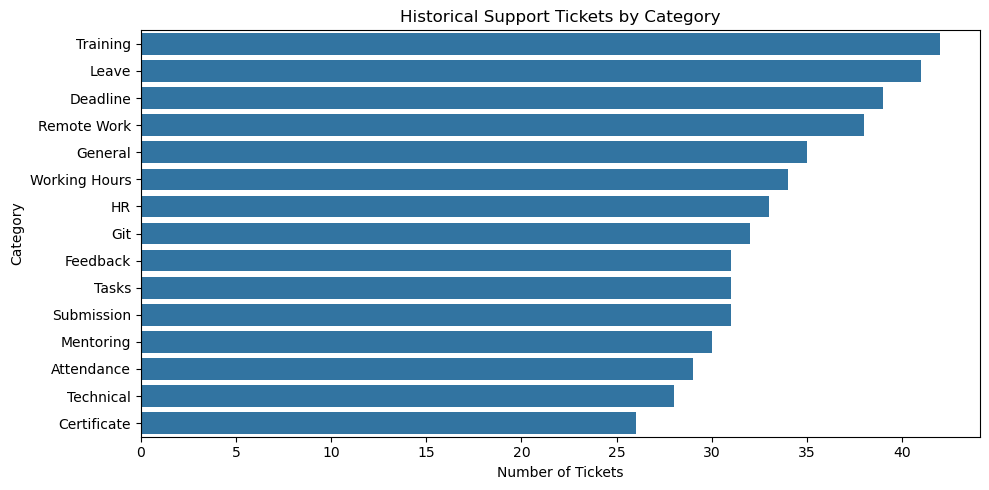

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(data=tickets, y="category", order=tickets["category"].value_counts().index)
plt.title("Historical Support Tickets by Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## Build the NLP Knowledge Base


In [5]:
faq["search_text"] = (
    faq["question"].fillna("") + " " +
    faq["category"].fillna("") + " " +
    faq["keywords"].fillna("")
)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2)
)

faq_matrix = vectorizer.fit_transform(faq["search_text"])

print("TF-IDF matrix shape:", faq_matrix.shape)


TF-IDF matrix shape: (20, 199)


## Create the Chatbot Function



In [13]:
def chatbot_response(user_query, threshold=0.20):
    query_vector = vectorizer.transform([user_query])
    scores = cosine_similarity(query_vector, faq_matrix).flatten()

    best_index = scores.argmax()
    best_score = scores[best_index]

    result = faq.iloc[best_index]

    if best_score >= threshold:
        return {
            "response": result["answer"],
            "category": result["category"],
            "matched_question": result["question"],
            "confidence": round(float(best_score), 3)
        }
    else:
        return {
            "response": "I could not find a confident answer. Please contact your internship supervisor, HR, or support team.",
            "category": "Unknown",
            "matched_question": "No reliable FAQ match",
            "confidence": round(float(best_score), 3)
        }


## Test the Chatbot

Try different intern questions. The chatbot should retrieve an appropriate FAQ answer.


In [7]:
test_questions = [
    "How can I mark my attendance?",
    "I forgot to check in today",
    "Where do I upload my assignment?",
    "I need extra time for my task",
    "How can I reach my mentor?",
    "When do I get my internship certificate?"
]

for q in test_questions:
    result = chatbot_response(q)
    print("Intern:", q)
    print("Bot:", result["response"])
    print("Category:", result["category"])
    print("Confidence:", result["confidence"])
    print("-" * 80)


Intern: How can I mark my attendance?
Bot: Inform your supervisor or HR as soon as possible and explain the missed attendance entry. Follow the organization's correction procedure.
Category: Attendance
Confidence: 0.607
--------------------------------------------------------------------------------
Intern: I forgot to check in today
Bot: I could not find a confident answer. Please contact your internship supervisor, HR, or support team.
Category: Unknown
Confidence: 0.168
--------------------------------------------------------------------------------
Intern: Where do I upload my assignment?
Bot: Complete the task according to the instructions, upload the required files or repository link, and submit it through the designated task platform.
Category: Submission
Confidence: 0.432
--------------------------------------------------------------------------------
Intern: I need extra time for my task
Bot: Read the task description first, then ask your supervisor or mentor for clarification

## Use Historical Support Tickets


In [8]:
ticket_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2)
)

ticket_matrix = ticket_vectorizer.fit_transform(tickets["query"])

def historical_ticket_response(user_query, threshold=0.20):
    query_vector = ticket_vectorizer.transform([user_query])
    scores = cosine_similarity(query_vector, ticket_matrix).flatten()

    best_index = scores.argmax()
    best_score = scores[best_index]

    ticket = tickets.iloc[best_index]

    if best_score >= threshold:
        return {
            "response": ticket["resolution"],
            "category": ticket["category"],
            "matched_ticket": ticket["query"],
            "confidence": round(float(best_score), 3)
        }
    return None


## Combined FAQ + Historical Ticket Chatbot


In [9]:
def support_chatbot(user_query, faq_threshold=0.20, ticket_threshold=0.20):
    faq_result = chatbot_response(user_query, threshold=faq_threshold)

    if faq_result["category"] != "Unknown":
        faq_result["source"] = "FAQ Knowledge Base"
        return faq_result

    ticket_result = historical_ticket_response(
        user_query,
        threshold=ticket_threshold
    )

    if ticket_result:
        ticket_result["source"] = "Historical Support Ticket"
        return ticket_result

    return {
        "response": "Sorry, I could not confidently answer that question. Please contact your internship support team.",
        "category": "Unknown",
        "matched_question": "No reliable match",
        "confidence": 0.0,
        "source": "Fallback"
    }


## Interactive Chatbot


In [10]:
while True:
    user_query = input("Intern: ")

    if user_query.lower() == "exit":
        print("Bot: Goodbye! Please contact support if you need further help.")
        break

    result = support_chatbot(user_query)

    print("\nBot:", result["response"])
    print("Category:", result["category"])
    print("Source:", result["source"])
    print("Confidence:", result["confidence"])
    print()


Intern:  I forgot to mark my attendance today



Bot: Inform your supervisor or HR as soon as possible and explain the missed attendance entry. Follow the organization's correction procedure.
Category: Attendance
Source: FAQ Knowledge Base
Confidence: 0.641



Intern:  How do I access the internship portal?



Bot: Use the internship portal link provided by HR. Sign in with your registered email and password. If you cannot log in, contact the internship support team.
Category: General
Source: FAQ Knowledge Base
Confidence: 0.74



Intern:  Where can I find training material?



Bot: Check the training portal, shared drive, learning-management system, or links provided by your mentor or HR.
Category: Training
Source: FAQ Knowledge Base
Confidence: 0.853



Intern:  exit


Bot: Goodbye! Please contact support if you need further help.


## Evaluate Retrieval on Known Queries


In [11]:
evaluation_questions = [
    ("How do I login to the portal?", "General"),
    ("I missed attendance today", "Attendance"),
    ("Where should I submit my task?", "Submission"),
    ("Can I get more time for my assignment?", "Deadline"),
    ("How do I reach my mentor?", "Mentoring"),
    ("How can I request leave?", "Leave"),
    ("Where is the training content?", "Training"),
    ("How is my internship performance measured?", "Performance")
]

evaluation_results = []

for question, expected_category in evaluation_questions:
    result = support_chatbot(question)
    evaluation_results.append({
        "question": question,
        "expected_category": expected_category,
        "predicted_category": result["category"],
        "confidence": result["confidence"],
        "correct": result["category"] == expected_category
    })

evaluation_df = pd.DataFrame(evaluation_results)
display(evaluation_df)

accuracy = evaluation_df["correct"].mean()
print(f"Category retrieval accuracy on this small test set: {accuracy:.2%}")


,question,expected_category,predicted_category,confidence,correct
0,How do I login to the portal?,General,General,0.538,True
1,I missed attendance today,Attendance,Attendance,0.662,True
2,Where should I submit my task?,Submission,Submission,0.612,True
3,Can I get more time for my assignment?,Deadline,Submission,0.250,False
4,How do I reach my mentor?,Mentoring,Mentoring,0.420,True
5,How can I request leave?,Leave,Leave,0.662,True
6,Where is the training content?,Training,Training,0.633,True
7,How is my internship performance measured?,Performance,Performance,0.575,True


Category retrieval accuracy on this small test set: 87.50%


## Save a Chatbot Response Report

In [12]:
sample_queries = [
    "How do I access the portal?",
    "I forgot my attendance",
    "Where are my tasks?",
    "Can I request leave?",
    "How can I submit code?",
    "Who can help with HR questions?",
    "How do I get feedback?"
]

response_rows = []

for q in sample_queries:
    result = support_chatbot(q)
    response_rows.append({
        "user_query": q,
        "category": result["category"],
        "confidence": result["confidence"],
        "source": result["source"],
        "response": result["response"]
    })

response_report = pd.DataFrame(response_rows)
display(response_report)

response_report.to_csv("chatbot_response_report.csv", index=False)

with pd.ExcelWriter("intern_chatbot_report.xlsx", engine="openpyxl") as writer:
    response_report.to_excel(writer, sheet_name="Chatbot Responses", index=False)
    evaluation_df.to_excel(writer, sheet_name="Evaluation", index=False)

print("Reports saved successfully.")


,user_query,category,confidence,source,response
0,How do I access the portal?,General,0.675,FAQ Knowledge Base,Use the internship portal link provided by HR....
1,I forgot my attendance,Attendance,0.590,FAQ Knowledge Base,Inform your supervisor or HR as soon as possib...
2,Where are my tasks?,Tasks,0.640,FAQ Knowledge Base,Assigned tasks are normally available in the p...
3,Can I request leave?,Leave,0.662,FAQ Knowledge Base,Submit a leave request through the organizatio...
4,How can I submit code?,Git,0.438,FAQ Knowledge Base,"Create or update the assigned repository, comm..."
5,Who can help with HR questions?,HR,0.460,FAQ Knowledge Base,Contact the HR representative or internship co...
6,How do I get feedback?,Feedback,0.710,FAQ Knowledge Base,Ask your mentor or supervisor for feedback dur...


Reports saved successfully.
